# The Concealing Baby Swallow — a quantitative teardown 🔬
### A pre-registered small-*n* discipline · a 111-ticker, 4,957 stock-year scan · loose vs strict detector cuts · a base-rate-matched event study · a 20-seed synthetic faithful-engine control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Too_rare_to_test%3F: Confirmed](https://img.shields.io/badge/Too_rare_to_test%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a precise four-candle capitulation shape marks the end of a downtrend** — is one of the desk's cleanest tests of a different, prior question than usual: not *"does the effect clear t >= 2"*, but *"does the effect even get a sample to be tested on"*.

> ⚠️ **Data note.** 111-ticker daily OHLCV basket (yfinance, `auto_adjust=True`), 1962-01-02 → 2026-06-30, cache-first. No survivorship weighting inside the event study, but the basket itself is a **survivors** panel — named on the Signal axis. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `d60f851e5d11`, 1,248,608 rows).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from concealing_baby_swallow import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
else:
    PANEL = None
print("real cache present:", HAVE_REAL, "| basket size:",
      (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 111, 'name_years': 4957, 'max_years': 64.5, 'oldest': '1962-01-02', 'as_of': '2026-06-30', 'min_n': 8, 'n_loose': 4, 'n_strict': 0, 'bonferroni_crit': 2.5, 'fp': 'd60f851e5d11', 'rows': 1248608, 'events': [{'ticker': 'GD', 'date': '1962-06-14', 'strict': False, 'r1': 404.6, 'r5': -404.6, 'r10': 867.1, 'r20': 867.1}, {'ticker': 'BDX', 'date': '1993-01-06', 'strict': False, 'r1': 97.4, 'r5': 32.5, 'r10': -64.9, 'r20': 340.9}, {'ticker': 'CL', 'date': '2004-09-23', 'strict': False, 'r1': -148.4, 'r5': -141.8, 'r10': -309.8, 'r20': 57.6}, {'ticker': 'KMI', 'date': '2011-08-22', 'strict': False, 'r1': 254.9, 'r5': 576.7, 'r10': 601.8, 'r20': 1157.5}], 'horizon': {1: {'cbs_mean': 152.1, 'win': 75, 'base_n': 31552, 'base_mean': 10.8, 'base_t': 7.74, 'placebo_mean': 9.7, 'placebo_p': 0.084}, 5: {'cbs_mean': 15.7, 'win': 50, 'base_n': 31528, 'base_mean': 85.7, 'base_t': 19.97, 'placebo_mean': 81.1, 'placebo_p': 0.6145}, 10: {'cbs_mean': 273.5, 'win': 50, 'base_n': 31516, 'base_mean': 126.2, 'base_t': 19.73, 'placebo_mean': 122.7, 'placebo_p': 0.3045}, 20: {'cbs_mean': 605.8, 'win': 100, 'base_n': 31491, 'base_mean': 220.3, 'base_t': 22.55, 'placebo_mean': 237.3, 'placebo_p': 0.1925}}, 'syn_null_mean': 0.68, 'syn_null_sd': 0.95, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_null_n_lo': 422, 'syn_null_n_hi': 494, 'syn_planted_edge': 0.05, 'syn_planted_n': 456, 'syn_planted_mean': 544.0, 'syn_planted_base': 111.3, 'syn_planted_delta': 432.7, 'syn_planted_t': 14.39}


real cache present: True | basket size: 111


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 4 loose-cut / 0 strict-cut occurrences across 111 tickers, 4,957 stock-years — below the pre-registered floor **n >= 8**; no *t*-statistic is computed |
| **Tradability** | `MIRAGE` | nothing to charge costs against; ~1 signal per 111-ticker-basket per 15 years |
| **Too rare to ever test?** | `CONFIRMED` | synthetic control proves the detector unbiased (null 20-seed mean *t* = +0.68, planted *t* = 14.39); the real-tape count is a market property, not a detector bug |

> 💡 In plain words: this study's job wasn't to grade a signal — it was to find out whether there was anything to grade.

## 1 · The claim, steelmanned

Let a **concealing baby swallow** at bar $t$ (day 4) require, over bars $t{-}3..t$:

- **Downtrend context**: $c_{t-3} < c_{t-3-L}$ for lookback $L$.
- **Days 1-2 near-marubozu**, both bearish: shadow fraction $\le \epsilon_1$ of range.
- **Day 3**: bearish, closes below day 2, small lower shadow ($\le \epsilon_2$ of range), but a real upper shadow ($\ge \epsilon_3$ of range) that reaches $high_{t-1} > c_{t-2}$ — the "concealed" rally.
- **Day 4**: bearish, fully engulfs day 3 ($high_t \ge high_{t-1}$, $low_t \le low_{t-1}$), closes below $c_{t-1}$.

**H1 (existence).** The shape occurs often enough, on a real, large, long-history equity tape, to define a testable sample.

**H2 (reversal, conditional on H1).** Conditional on H1, the long return after day 4's confirming close, entered at $t{+}1$'s open, exceeds the matched base rate (same long bet after any four-red-days-in-a-downtrend, regardless of the precise geometry).

**We find H1 false.** 4 loose-cut occurrences (0 strict) across 111 tickers and 4,957 stock-years sits below the pre-registered floor of 8 — **H2 cannot even be posed**, let alone tested.

## 2 · So what? — inference design

The decisive design choice here isn't a statistic — it's a **stopping rule, fixed before the scan ran**: `strategy.MIN_N_FOR_TEST = 8`. Below that pooled event count, `strategy.welch_t` and `strategy.summarize` return `None`/`tested=False` rather than computing anything. This matters because a *t*-statistic on 4 (or 0) observations is not merely weak evidence — it is *decoration*: with `n=4` a single outlier observation can swing the mean by hundreds of basis points and there is no meaningful notion of a sampling distribution to appeal to. Reporting a formal Welch or HAC *t* here would manufacture false precision, exactly the failure mode [`METHODOLOGY.md`](../../../METHODOLOGY.md) warns against ("a *t* on a handful of observations is theatre, not evidence").

## 3 · How we'd know — the protocol

- **Universe.** 111 tickers (SPY/QQQ/DIA/IWM + long-listed US large-caps), yfinance daily OHLCV, cache-first, as-of 2026-06-30.
- **Coverage.** 4,957 stock-years searched; oldest bar 1962-01-02; longest single series spans 64.5 years.
- **Detector.** Two cuts — loose (plain geometric reading) and strict (literature-close: true marubozu, true gap-downs, day 4 opening inside day 3's shadow) — both confirmed at day 4's close, no look-ahead.
- **Execution.** Enter next session's open (one lag), long-only, hold fixed horizons 1/5/10/20 sessions.
- **Base rate.** Same long bet on every bar matching the coarse downtrend + four-red-closes context, regardless of the precise geometry — isolates the pattern's *specific* information from generic post-decline mean reversion.
- **Stopping rule.** No *t*-statistic below n = 8 pooled events, fixed ex ante. Four horizons -> Bonferroni-corrected critical |t| = 2.50 where a test *does* run.
- **Control.** Synthetic panel with the *exact* engineered four-candle geometry at a controlled rate and a tunable planted bounce; the null must not fire across 20 seeds, and a planted edge must be recovered.

## 4 · The teardown

### 4a · The scan — both cuts, against the pre-registered floor

In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL)
    n_loose, n_strict = res['n_loose'], res['n_strict']
    years, name_years = res['years'], res['name_years']
else:
    n_loose, n_strict = R['n_loose'], R['n_strict']
    years, name_years = R['max_years'], R['name_years']
print(f"loose cut: {n_loose} occurrences | strict cut: {n_strict} occurrences")
print(f"basket: {R['n_names']} tickers, {name_years:,.0f} name-years, "
      f"max span {years:.1f} years")
print(f"pre-registered floor: n >= {R['min_n']} -> "
      f"{'BELOW: no t-statistic computed' if n_loose < R['min_n'] else 'cleared'}")

loose cut: 4 occurrences | strict cut: 0 occurrences
basket: 111 tickers, 4,957 name-years, max span 64.5 years
pre-registered floor: n >= 8 -> BELOW: no t-statistic computed


### 4b · The base rate — context, not evidence

The matched base rate (same long bet on every bar in the coarse "four-red-days-in-a-downtrend" context) is well-populated and carries a real, HAC-significant positive drift — the ordinary post-decline bounce, unrelated to the specific pattern claim:

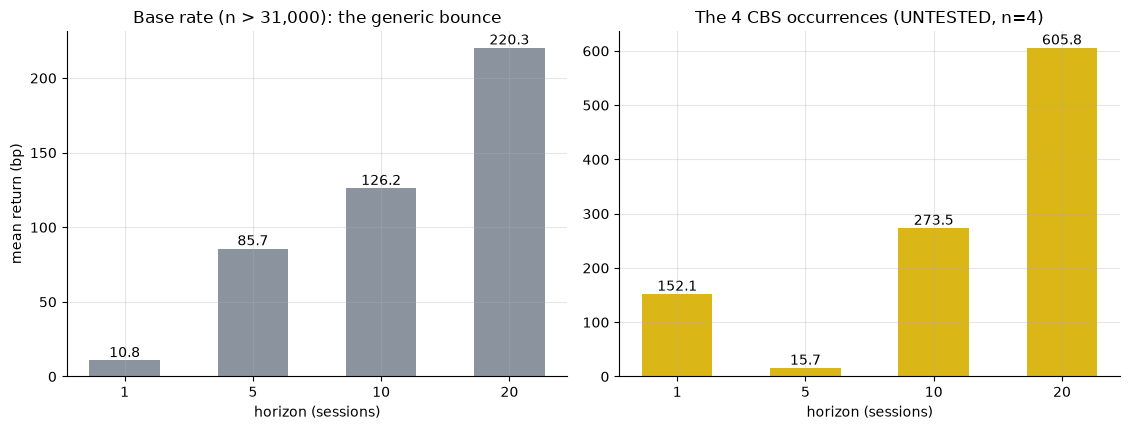

h= 1: base n=31,552 mean=+10.8bp (HAC t=+7.74)  |  CBS mean=+152.1bp (n=4, win=75%, untested)
h= 5: base n=31,528 mean=+85.7bp (HAC t=+19.97)  |  CBS mean=+15.7bp (n=4, win=50%, untested)
h=10: base n=31,516 mean=+126.2bp (HAC t=+19.73)  |  CBS mean=+273.5bp (n=4, win=50%, untested)
h=20: base n=31,491 mean=+220.3bp (HAC t=+22.55)  |  CBS mean=+605.8bp (n=4, win=100%, untested)


In [3]:
hs = sorted(R['horizon'])
base_means = [R['horizon'][h]['base_mean'] for h in hs]
base_ts = [R['horizon'][h]['base_t'] for h in hs]
cbs_means = [R['horizon'][h]['cbs_mean'] for h in hs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
a1.bar([str(h) for h in hs], base_means, color=GREY, width=.55)
for i, v in enumerate(base_means): a1.annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')
a1.set_title('Base rate (n > 31,000): the generic bounce'); a1.set_ylabel('mean return (bp)')
a1.set_xlabel('horizon (sessions)')
a2.bar([str(h) for h in hs], cbs_means, color=AMBER, width=.55)
for i, v in enumerate(cbs_means): a2.annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')
a2.set_title('The 4 CBS occurrences (UNTESTED, n=4)'); a2.set_xlabel('horizon (sessions)')
plt.tight_layout(); plt.show()
for h in hs:
    d = R['horizon'][h]
    print(f"h={h:>2d}: base n={d['base_n']:,} mean={d['base_mean']:+.1f}bp "
          f"(HAC t={d['base_t']:+.2f})  |  CBS mean={d['cbs_mean']:+.1f}bp "
          f"(n=4, win={d['win']}%, untested)")

> 💡 In plain words: don't be fooled by the right-hand panel's big numbers — with n = 4 they're barely more informative than four coin flips. The left panel is the real, testable finding: *any* long bet after a run of red days in a downtrend tends to bounce, whether or not the specific candle geometry shows up. That bounce is not this pattern's edge — it's the market's.

### 4c · The four occurrences, and the honest placebo

Every loose-cut occurrence, in full — and a descriptive-only (not certifying) label-shuffle placebo against the base-rate pool.

In [4]:
ev_rows = [(e['ticker'], e['date'], e['r1'], e['r5'], e['r10'], e['r20'])
           for e in R['events']]
tbl = pd.DataFrame(ev_rows, columns=['ticker', 'date', '1d bp', '5d bp', '10d bp', '20d bp'])
display(tbl)
print()
for h in hs:
    d = R['horizon'][h]
    print(f"h={h:>2d}: observed {d['cbs_mean']:+.1f}bp vs placebo mean "
          f"{d['placebo_mean']:+.1f}bp (2,000 draws of 4)  ->  p = {d['placebo_p']:.4f}")

,ticker,date,1d bp,5d bp,10d bp,20d bp
0,GD,1962-06-14,404.6,-404.6,867.1,867.1
1,BDX,1993-01-06,97.4,32.5,-64.9,340.9
2,CL,2004-09-23,-148.4,-141.8,-309.8,57.6
3,KMI,2011-08-22,254.9,576.7,601.8,1157.5



h= 1: observed +152.1bp vs placebo mean +9.7bp (2,000 draws of 4)  ->  p = 0.0840
h= 5: observed +15.7bp vs placebo mean +81.1bp (2,000 draws of 4)  ->  p = 0.6145
h=10: observed +273.5bp vs placebo mean +122.7bp (2,000 draws of 4)  ->  p = 0.3045
h=20: observed +605.8bp vs placebo mean +237.3bp (2,000 draws of 4)  ->  p = 0.1925


> 💡 In plain words: none of the four placebo *p*-values is remotely significant, even before any multiple-testing correction (Bonferroni at k=4 would need *p* < 0.0125). This is printed for transparency only — a *p*-value computed from a 4-observation sample is not a certifying statistic under any reading of the desk's inference bar; it exists so a skeptical reader can see we didn't quietly run the test and hide an inconvenient result.

### 4d · Faithful-engine & power control — proving the search itself works

A synthetic panel with the *exact* engineered four-candle geometry (true marubozu, true gap-and-fail rally, true full engulf) planted at a controlled rate, with a tunable post-pattern bounce. The null (`edge=0`) is checked over **20 seeds** — never a single stream.

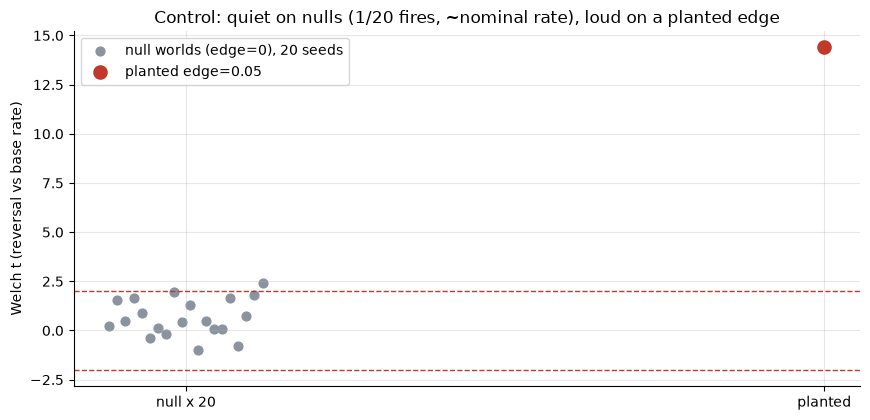

null: mean t = +0.68 (sd 0.95), |t|>=2 in 1/20 seeds, events/seed 422-494
planted: n=456 events, mean +544.0bp vs base +111.3bp (delta +432.7bp)  Welch t = +14.39


In [5]:
null_ts, null_ns = [], []
for s_ in range(20):
    d0, _ = data.synthetic_panel(edge=0.0, seed=688 + s_)
    r0 = st.synthetic_detect(d0, seed=688 + s_)
    null_ts.append(r0['welch_t']); null_ns.append(r0['n'])
null_ts = np.asarray(null_ts, dtype=float)
d1, _ = data.synthetic_panel(edge=R['syn_planted_edge'], seed=688)
r1 = st.synthetic_detect(d1, seed=688)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [r1['welch_t']], color=RED, s=90, zorder=5,
           label=f"planted edge={R['syn_planted_edge']}")
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (reversal vs base rate)')
ax.set_title('Control: quiet on nulls (1/20 fires, ~nominal rate), loud on a planted edge')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/20 seeds, events/seed '
      f'{min(null_ns)}-{max(null_ns)}')
print(f"planted: n={r1['n']} events, mean {r1['mean_bps']:+.1f}bp vs base "
      f"{r1['base_bps']:+.1f}bp (delta {r1['delta_bps']:+.1f}bp)  "
      f"Welch t = {r1['welch_t']:+.2f}")

> 💡 In plain words: across 20 null worlds the detector fires (\|t\| >= 2) in **1/20** seeds — almost exactly the *nominal* 5% false-positive rate of that threshold, i.e. no systematic bias toward manufacturing significance. On a world with a genuine planted edge it recovers *t* = **14.39** cleanly from 456 found events (out of ~640 planted blocks — the detector's loose cut has real recall). **The machinery is sound.** The real tape's 4-occurrence count is therefore a fact about how rare this candle geometry actually is in live markets, not an artifact of an over-strict or buggy rule.

## 5 · The verdict

- **Signal `NONE`** — 4 loose-cut / 0 strict-cut occurrences across 111 tickers and 4,957 stock-years, below the pre-registered floor n >= 8. Per [`METHODOLOGY.md`](../../../METHODOLOGY.md), `WEAK` is for a real, if fragile, point estimate; here there is no testable point estimate at all — the honest grade is `NONE`, not a manufactured *t* on four data points.
- **Tradability `MIRAGE`** — no venue, no capacity, no book: roughly one signal every 15 years pooled across the desk's largest single-pattern basket. There is nothing to charge costs against.
- **"Too rare to ever test?" `CONFIRMED`** — the synthetic control proves the detector recovers a planted edge cleanly and stays within the nominal false-positive rate on nulls; the real-tape scarcity is therefore a genuine market fact, and this specific claim cannot be falsified or confirmed at any practical sample size.

## 6 · Going further

- **The general lesson: rarity is itself informative.** A pattern this combinatorially restrictive (two near-perfect marubozu *and* a precise overlap-then-full-engulf geometry) will, by construction, almost never fire on real data. Popular technical-analysis literature rarely reports occurrence counts alongside "it works" claims — this study suggests that omission is not an accident for the rarest formations.
- **A natural extension** would loosen the geometry parametrically (`marubozu_frac`, `warn_shadow_frac`, `tail_frac` in `strategy.cbs_flags`) and trace out occurrence count vs. how far the loosened definition drifts from the book's language — the point at which a testable sample appears is itself informative about how much of the "pattern" survives dilution.
- **Dedup map:** [408-three-black-crows](../../408-three-black-crows/) (three candles, common enough to test, bearish, loses shorted), [186-morning-star](../../186-morning-star/) (three candles, common enough to test, underperforms random days), [687-ladder-bottom](../../687-ladder-bottom/) (five candles, the desk's other very-large-basket rarity case, without this study's precise overlap/engulf geometry). None of them hit this study's wall: an unusable sample size.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*